<h1 style="color: orange; font-size: 40px; font-weight: bold;">
LAB 8
</h1>

<h2 style="color: green; font-size: 35px; font-weight: bold;">
Variational Monte Carlo with simulated annealing
</h2>

<p style="color: blue; font-size: 25px; font-weight: bold;">
Variational Principle
</p>

One of the most used approaches to tackle non-analytical solvable system is the variational principle, which states that the local energy evaluated with any (good) chosen form of the wave function will always be greater than the actual ground state energy of the system
$$
\langle H\rangle _T=\frac{\int dx\psi _T^*(x)H\psi _T(x)}{\int dx|\psi _T(x)|^2}\geq\frac{\braket{\psi _0|H|\psi _0}}{\braket{\psi _0|\psi _0}}
$$
In this exercise, the focus is on a 1D particle subjected to the potential:
$$
V(x)=x^4-\frac{5}{2}x^2
$$
And the ansatz is chosen as
$$
\psi _T^{\mu,\sigma}\sim e^{-\frac{(x-\mu)^2}{\sigma^2}}+e^{-\frac{(x+\mu)^2}{\sigma^2}}
$$
two other tools are needed: an algorithm to sample from (without knowing its normalization constant) and an algorithm to choose the parameters that minimize the loss.
The following plots shows the energy for the un-optimized system, with $\mu=1.2, \ \sigma=0.5$ and 50 blocks used with 2000 step for block. The lenght of the metropolis step is set to 2.1.

Energy with no optimal parameters: E = 0.250 ± 0.004


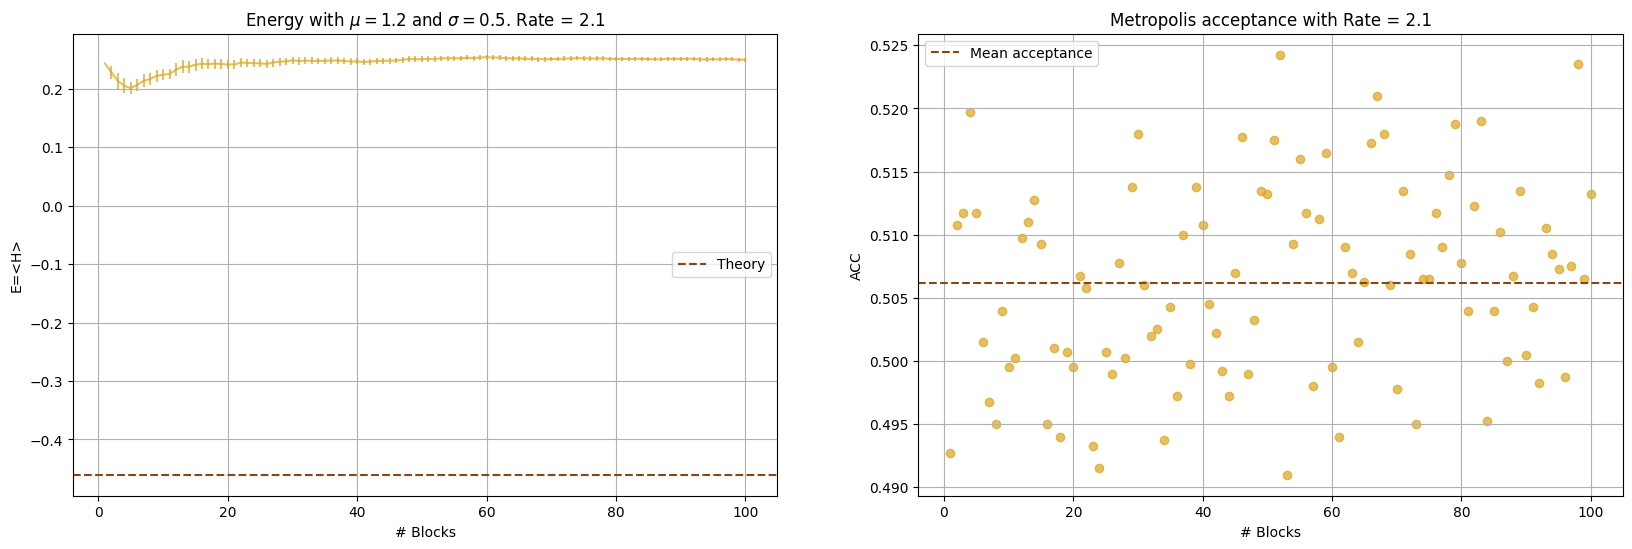

In [37]:
import numpy as np
import matplotlib.pyplot as plt

E_theory = -0.46046587969271513
data_acc = np.loadtxt("./OUTPUT/acceptance-1.dat", skiprows=1)
E_no_opt = np.loadtxt("./OUTPUT/Mean_energy_no_opt_p.dat", skiprows=1)
print(f"Energy with no optimal parameters: E = {E_no_opt[-1, 2]:.3f} ± {E_no_opt[-1, 3]:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(20, 6))
ax[0].errorbar(E_no_opt[:, 0], E_no_opt[:, 2], yerr=E_no_opt[:, 3], color="GoldenRod", alpha=0.7)
ax[0].grid(True)
ax[0].set_title(r"Energy with $\mu=1.2$ and $\sigma=0.5$. Rate = 2.1")
ax[0].set_xlabel("# Blocks")
ax[0].set_ylabel("E=<H>")
ax[0].axhline(E_theory, color='saddlebrown', label="Theory", ls='--')
ax[0].legend()
ax[1].scatter(data_acc[:, 0], data_acc[:, 1], color="GoldenRod", alpha=0.7)
ax[1].axhline(np.mean(data_acc[:, 1]), color='saddlebrown', label='Mean acceptance', ls='--')
ax[1].grid(True)
ax[1].set_title("Metropolis acceptance with Rate = 2.1")
ax[1].set_xlabel("# Blocks")
ax[1].set_ylabel("ACC")
ax[1].legend()
plt.show()

<p style="color: blue; font-size: 25px; font-weight: bold;">
Simulated annealing algorithm
</p>

Simulated annealing is an optimization algorithm inspired to the process of crystals formation, where the minimum energy is found through gradual cooling.

The key idea is to interpret the loss function $L(x)$ as the energy of a statistical-mechanics system, and to associate a Boltzmann distribution
$$
P(x)=\frac{e^{-\beta L(x)}}{Z}
$$
At high temperature, the distribution is broad, allowing exploration of the configuration space; as the temperature decreases, the probability becomes increasingly concentrated around the minima of L(x).

The idea is to sample the Boltzmann distribution at progressively lower temperatures in order to seek the optimal variational parameters. Once the system has equilibrated at a given temperature, the temperature is reduced and the optimization is repeated. 

The algorithm therefore involves two nested (M(RT)^2) samplings. The first operates in the parameter space, where the variational parameters are updated according to the Markov chain
$$
\begin{cases}
\mu'=\mu+r_p*Rannyu(-1, 1) \\
\sigma'=\sigma+r_p*Rannyu(-1, 1).
\end{cases}
$$
The role of this Metropolis algorithm is to sample the Boltzmann distribution over the space of variational parameters. For each proposed move, the energy difference $\Delta E=E(\mu', \sigma')-E(\mu, \sigma)$ is evaluated, and the proposal is accepted with
$$
\min[1,\ e^{\beta\Delta E}].
$$
Consequently, when $\Delta E<0$ the move is always accepted.
In particular it is employed in the optimizing process within the function `move_param(array<double, 2>& E_old)`.

The evaluation of the energy for a given set of variational parameters is performed by a second Metropolis algorithm, which samples the probability density associated with the trial wave function. At each proposed position $x'$, the local energy is evaluated and the move is accepted with probability
$$
A=\min[1,\ \frac{|\psi(x')|^2}{|\psi(x)|^2}].
$$
This sampling procedure is implemented in the function `move()`
Every time we evaluate energy, we use the data-blocking technique.

In particular, a few considerations are required for the choice of the simulation parameters.

The spatial step used by the Metropolis algorithm during the energy evaluation is scaled with the variational parameter $\sigma$. Since, for a Gaussian distribution, $\sigma$ represents its characteristic width, it provides a natural length scale for selecting the proposal step. Moreover, because the trial wave function is given by the superposition of two Gaussian functions, choosing the step size proportional to the width is particularly appropriate. Whenever $\sigma$ is updated during the optimization, the spatial step is updated accordingly:
$$
\delta x = r \sigma.
$$
where r is a constant that is tuned so that the average spatial acceptance rate at each temperature remains close to 50% throughout the simulation.

The second parameter to be adjusted is the update rate of the variational parameters. Since the goal is to perform an optimization rather than an efficient sampling, an acceptance rate of 50% is no longer the target. Instead, as the temperature decreases, the acceptance rate is expected to decrease as well, indicating that the system is progressively freezing and accepts only parameter updates that provide a genuine improvement of the energy.

For this reason, to imporve the quality of the algorithm, we introduce a temperature dependence in the number of SA step, accordingly to
$$
N_{moves}^{SA}(\beta)=N_0\bigg(\frac{\beta}{\beta _{start}}\bigg)^{0.3},
$$
where $N_0$ is the number of Metropolis step performed at $T_{start}$.
The range of temperature we have choosen is $T\in[0.03, 1.5]$, with $T_{end}=0.03$ and $T_{start}=1.5$. Finally, $N_0$ is set to 1000. As a consequence, at the final temperature the algorithm performs approximately 3.23 times more steps, corresponding to a total of 3230 steps.

The number of SA step depends on the range of temperature, as can be seen by
$$
SA_{step}=\frac{\log(\frac{T_{start}}{T_{end}})}{\log{c}}+1,
$$
where c is the cooling parameter, here set to 1.01. With these temperatures, the resulting number of SA steps is 394.

### SA optimization parameters:
```text
STEP_NUMBER        2000
BLOCK_NUMBER_SA    20
N_STEP_T_START     1000
RATE               2.0
RATE_PARAM         0.82
START_TEMPERATURE  1.5
COOLING            1.01
END_TEMPERATURE    0.03

ENDINPUT
```

During the optimization, it may happen that the lowest sampled energy is not obtained at the lowest temperature. This is a consequence of the stochastic nature of the sampling: the energy estimates are affected by statistical fluctuations. This is a consequence of the statistical nature of the sampling: the energy estimates are affected by statistical fluctuations.

Therefore, it is not good practice to identify the optimal parameters solely from the minimum sampled energy. Instead, the statistical uncertainties should also be taken into account when comparing different energy estimates.

Maximum acceptance during optimization: 0.535656, Minimum acceptance reached: 0.481731


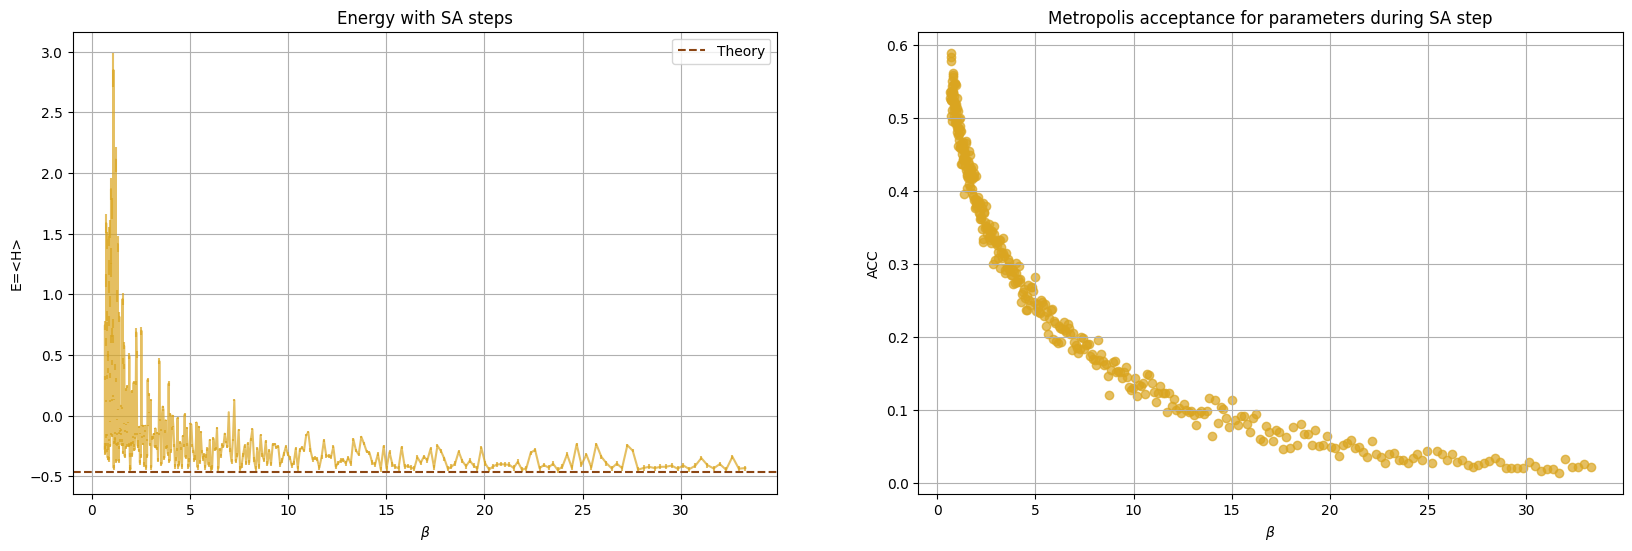

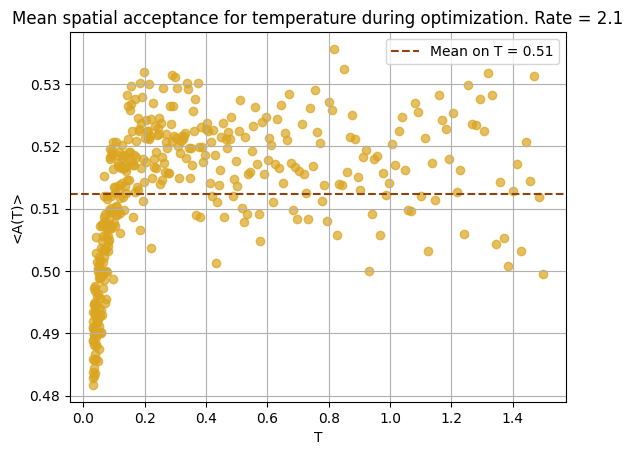

--------FINAL VALUES--------
final_temperature:  0.0300463
Best_mu =  0.753039
Best_sigma =  0.64876
Best_energy =  -0.431833
Best_energy_error =  0.021074
--------MINIMUM ENERGY VALUES--------
MIN_temperature:  0.0421423
Best_mu =  0.778581
Best_sigma =  0.623512
Best_energy =  -0.448313
Best_energy_error =  0.0218546


In [38]:
import numpy as np
import matplotlib.pyplot as plt

acc_during_opt = np.loadtxt("./OUTPUT/acceptance_space_temp.dat", skiprows=1)
acc_max_during = np.max(acc_during_opt[:, 1])
acc_min_during = np.min(acc_during_opt[:, 1])

print(f"Maximum acceptance during optimization: {acc_max_during}, Minimum acceptance reached: {acc_min_during}")

data = np.loadtxt("./OUTPUT/parameters_evolution.dat", skiprows=1)
acceptance_SA = np.loadtxt("./OUTPUT/acceptance_param.dat", skiprows=1)

T = data[:, 0]
mu = data[:, 1]
sigma = data[:, 2]
E = data[:, 3]
err_E = data[:, 4]
Acc_SA = acceptance_SA[:, 1]

fig, ax = plt.subplots(1, 2, figsize=(20, 6))
ax[0].errorbar(1/T, E, yerr=err_E, color="GoldenRod", alpha=0.7)
ax[0].grid(True)
ax[0].set_title("Energy with SA steps")
ax[0].set_xlabel(r"$\beta$")
ax[0].set_ylabel("E=<H>")
ax[0].axhline(E_theory, color='saddlebrown', label="Theory", ls='--')
ax[0].legend()
ax[1].scatter(1/T, Acc_SA, color="GoldenRod", alpha=0.7)
ax[1].grid(True)
ax[1].set_title("Metropolis acceptance for parameters during SA step")
ax[1].set_xlabel(r"$\beta$")
ax[1].set_ylabel("ACC")
plt.show()

T = acc_during_opt[:, 0]
M_A = acc_during_opt[:, 1]

plt.scatter(T, M_A, color='goldenrod', alpha=0.7)
plt.axhline(np.mean(M_A), color='saddlebrown', ls='--', label=f'Mean on T = {np.mean(M_A):.2f}')
plt.xlabel("T")
plt.ylabel("<A(T)>")
plt.title("Mean spatial acceptance for temperature during optimization. Rate = 2.1")
plt.legend()
plt.grid(True)
plt.show()

best_mu = mu[-1]
best_sigma = sigma[-1]
print("--------FINAL VALUES--------")
print("final_temperature: ", T[-1])
print("Best_mu = ", best_mu)
print("Best_sigma = ", best_sigma)
print("Best_energy = ", E[-1])
print("Best_energy_error = ", err_E[-1])

min = np.argmin(E)
best_mu1 = mu[min]
best_sigma1 = sigma[min]
print("--------MINIMUM ENERGY VALUES--------")
print("MIN_temperature: ", T[min])
print("Best_mu = ", best_mu1)
print("Best_sigma = ", best_sigma1)
print("Best_energy = ", E[min])
print("Best_energy_error = ", err_E[min])

As one can see, the minimum value of the energy is not reached at the final temperature, but before. Comparing the statistical error, one can also see that the two energy are statistically compatible, so the observed difference is therefore due to statistical fluctuations, making it appropriate to adopt the final set of variational parameters. The optimized values are
$$
\mu = 0.753039, \ \sigma = 0.64876.
$$
The following plots show the evolution of the energy in the parameter space and the exploration rate of the parameter space during the optimization process.

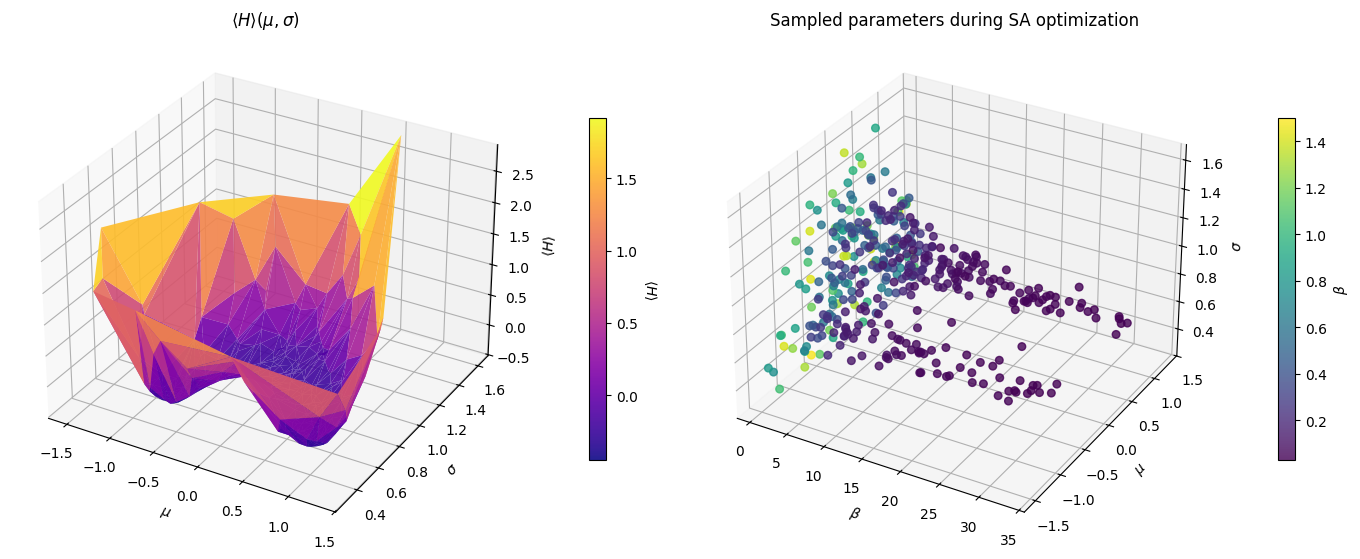

In [39]:
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_trisurf(mu, sigma, E, cmap='plasma', edgecolor='none', alpha=0.9)
ax1.set_xlabel(r'$\mu$')
ax1.set_ylabel(r'$\sigma$')
ax1.set_zlabel(r'$\langle H \rangle$')
ax1.set_title(r"$\langle H \rangle(\mu, \sigma)$")
cbar1 = fig.colorbar(surf, ax=ax1, shrink=0.6, pad=0.1)
cbar1.set_label(r"$\langle H \rangle$", rotation=270, labelpad=15)
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
sc = ax2.scatter(1/T, mu, sigma, c=T, cmap='viridis', s=30, alpha=0.8)
ax2.set_xlabel(r"$\beta$")
ax2.set_ylabel(r"$\mu$")
ax2.set_zlabel(r"$\sigma$")
ax2.set_title("Sampled parameters during SA optimization")
cbar2 = fig.colorbar(sc, ax=ax2, shrink=0.6, pad=0.1)
cbar2.set_label(r"$\beta$")
plt.tight_layout()
plt.show()

After the optimization, the best parameters found give out a good approximation for the atual wavefunction. From this one, mean energy and an histogram with the PDF $|\psi_{best}(x)|^2$ have been computed using data blocking, and then put in comparison with results obtained by translating Schroedinger's equation into matricial form. To do so, it is sufficient to discretize the space, and to evaluate $\psi(x)$ for each point on the grid.

### Optimize simulation parameters:
$$
\mu= , \\
\sigma=
$$
```text
STEP_NUMBER        2000
BLOCK_NUMBER       100
RATE               2.0
NUM_BINS           100

ENDINPUT
```

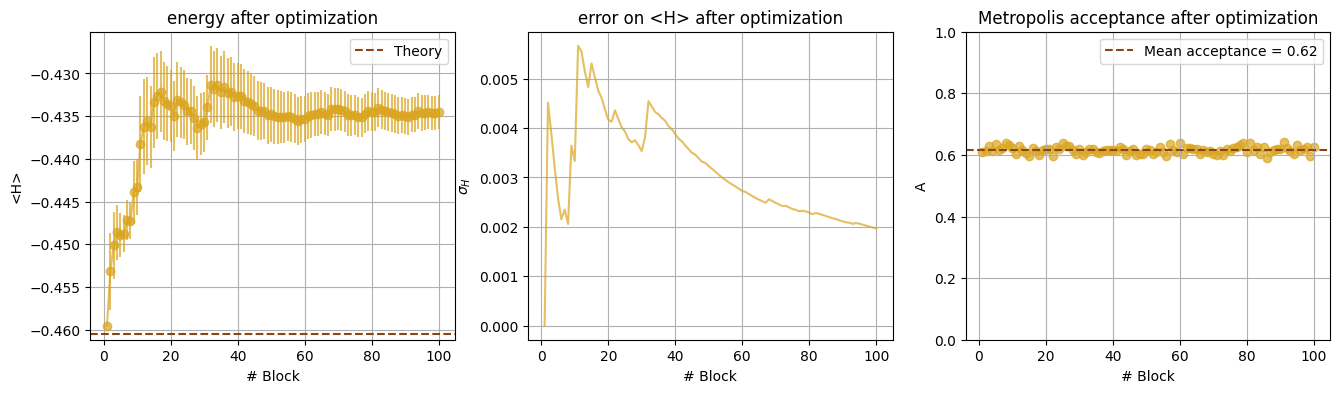

Energia ground state:  -0.46046587969271513
Enrgia simulazione: -0.434479 ± 0.0019692


In [40]:
dataopt = np.loadtxt("./OUTPUT/Mean_energy_opt_p.dat")

N = dataopt[:, 0]
Hopt = dataopt[:, 2]
error_opt = dataopt[:, 3]

fig, ax = plt.subplots( 1, 3, figsize=(16,4))

ax[0].errorbar(N, Hopt, yerr=error_opt, fmt='-o', color= 'GoldenRod', alpha=0.7)
ax[0].grid(True)
ax[0].set_xlabel("# Block")
ax[0].set_ylabel("<H>")
ax[0].set_title("energy after optimization")
ax[0].axhline(-0.46046587969271513, color='saddlebrown', label="Theory", ls='--')
ax[0].legend()
ax[1].plot(N, error_opt, color= 'GoldenRod', alpha=0.7)
ax[1].grid(True)
ax[1].set_xlabel("# Block")
ax[1].set_ylabel(r"$\sigma_H$")
ax[1].set_title("error on <H> after optimization")
acc=np.loadtxt("OUTPUT/acceptance.dat")
Na=acc[:,0]
acc=acc[:,1]
ax[2].scatter(Na, acc, color= 'GoldenRod', alpha=0.7)
ax[2].axhline(np.mean(acc), color='saddlebrown', ls='--', label=f'Mean acceptance = {np.mean(acc):.2f}')
ax[2].grid(True)
ax[2].set_xlabel("# Block")
ax[2].set_ylabel("A")
ax[2].set_ylim(0.0,1.0)
ax[2].legend()
ax[2].set_title("Metropolis acceptance after optimization")

plt.show()

print("Energia ground state: ", -0.46046587969271513)
print(f"Enrgia simulazione: {Hopt[-1]} ± {error_opt[-1]}")

Best mu =  0.753039
Best_sigma =  0.64876


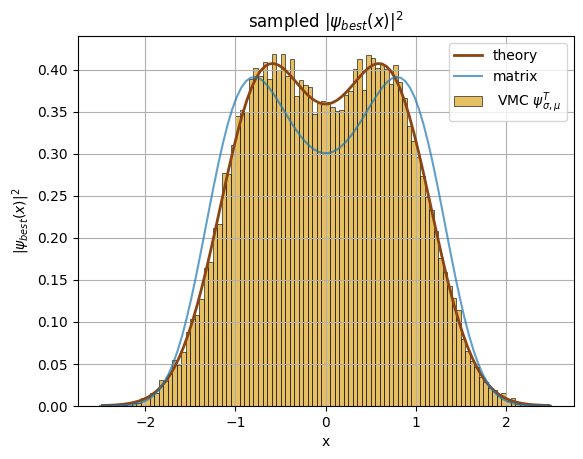

In [ ]:
def Vpot(x):
    return (x**2 - 2.5)*x**2
hbar = 1
m = 1
a = 5
N = 100
x = np.linspace(-a/2, a/2, N)
dx = x[1] - x[0]  # passo
V = Vpot(x)
CDiff = np.diag(np.ones(N-1),-1)-2*np.diag(np.ones(N),0)+np.diag(np.ones(N-1),1)
H = (-(hbar**2)*CDiff)/(2*m*dx**2) + np.diag(V)
E, psi = np.linalg.eigh(H)
psi = np.transpose(psi)
psi = psi/np.sqrt(dx)


def Psi2Real(x,mu,sigma):
    term1 = np.exp(-((x-mu)**2)/(2*sigma**2))
    term2 = np.exp(-((x+mu)**2)/(2*sigma**2))
    psi = term1+term2
    return psi**2
datapdf = np.loadtxt("OUTPUT/pdf.dat")
#bins=datapdf[:,0]
pdf = datapdf
nbins = len(pdf)
bin_size = (a)/nbins#xmax-xmin/nbins
pdf /= (np.sum(pdf)*bin_size) #normalize
xhist = np.linspace(-a/2+bin_size/2,a/2-bin_size/2,nbins)

print("Best mu = ", best_mu)
print("Best_sigma = ", best_sigma)
plt.bar(xhist, pdf, width=bin_size, align='center', alpha=0.7, color='GoldenRod', edgecolor='black', linewidth=0.6, label=r' VMC $\psi^T_{\sigma,\mu}$')
y = Psi2Real(xhist, best_mu, best_sigma)
y /= np.trapz(y, xhist) #normalize theoretical distribution integrating with trapezoid method
plt.plot(xhist, y, color='saddlebrown', linewidth=2.0, label='theory')
plt.xlabel('x')
plt.ylabel(r'$|\psi_{best}(x)|^2$')
plt.title(r'sampled $|\psi_{best}(x)|^2$')
plt.grid(True)
plt.plot(x,(psi[0])**2, label='matrix', alpha=0.7)
plt.legend()
plt.show()